In [1]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"GPU available : {torch.cuda.is_available()}")
print(f"Device        : {device}")
if torch.cuda.is_available():
    print(f"GPU name      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


GPU available : True
Device        : cuda
GPU name      : Tesla T4
VRAM          : 15.6 GB


In [2]:
!pip install ultralytics onnx onnxruntime pybullet opencv-python matplotlib -q
print("All dependencies installed.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 73.1 MB/s eta 0:00:00
All dependencies installed.


In [3]:
import cv2
import numpy as np
import os
import pybullet_data

# ── Create synthetic warehouse video ────────────────────────────────────────
out = cv2.VideoWriter(
    '/content/warehouse.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    30, (640, 480)
)

for i in range(200):  # 200 frames = ~6.7 seconds at 30fps
    frame = np.ones((480, 640, 3), dtype=np.uint8) * 60  # dark background

    # Person 1 — moves left to right
    x1 = int(50 + i * 2.0) % 600
    cv2.rectangle(frame, (x1, 150),    (x1+50, 300), (180, 120, 80),  -1)  # body
    cv2.circle(frame,    (x1+25, 130), 25,            (200, 160, 120), -1)  # head

    # Person 2 — moves right to left
    x2 = int(500 - i * 1.5) % 600
    cv2.rectangle(frame, (x2, 170),    (x2+50, 320), (100, 140, 180),  -1)
    cv2.circle(frame,    (x2+25, 150), 25,            (200, 160, 120), -1)

    # Static background elements (shelf + floor)
    cv2.rectangle(frame, (0, 350),   (640, 480), (40, 40, 40), -1)
    cv2.rectangle(frame, (200, 200), (400, 350), (80, 80, 80), -1)

    out.write(frame)

out.release()

size = os.path.getsize('/content/warehouse.mp4')
print(f"Video created  : /content/warehouse.mp4")
print(f"File size      : {size/1024:.1f} KB")
print(f"Frames         : 200 @ 30fps (~6.7 seconds)")
print(f"PyBullet data  : {pybullet_data.getDataPath()}")
print(f"Status         : {'✅ Ready' if size > 1000 else '❌ Failed'}")


Video created  : /content/warehouse.mp4
File size      : 180.1 KB
Frames         : 200 @ 30fps (~6.7 seconds)
PyBullet data  : /usr/local/lib/python3.12/dist-packages/pybullet_data
Status         : ✅ Ready


In [4]:
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
import time

# ── Start simulator ──────────────────────────────────────────────────────────
physicsClient = p.connect(p.DIRECT)          # DIRECT = no GUI (Colab-compatible)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)                    # Earth gravity (m/s²)

# ── Load scene ───────────────────────────────────────────────────────────────
planeId  = p.loadURDF("plane.urdf")
robotId  = p.loadURDF("kuka_iiwa/model.urdf",
                       basePosition=[0, 0, 0],
                       useFixedBase=True)     # fixed base = arm bolted to floor

# Place 3 objects in the robot's workspace
obj1 = p.loadURDF("cube_small.urdf",   basePosition=[ 0.5,  0.0, 0.1])
obj2 = p.loadURDF("cube_small.urdf",   basePosition=[ 0.4,  0.3, 0.1])
obj3 = p.loadURDF("sphere_small.urdf", basePosition=[ 0.3, -0.2, 0.1])

objects = {
    'cube_1': p.getBasePositionAndOrientation(obj1)[0],
    'cube_2': p.getBasePositionAndOrientation(obj2)[0],
    'sphere': p.getBasePositionAndOrientation(obj3)[0],
}

# Step simulation — let physics settle
for _ in range(100):
    p.stepSimulation()

print("Simulation loaded ✅")
print(f"Robot model    : Kuka iiwa")
print(f"Robot joints   : {p.getNumJoints(robotId)} DOF")
print(f"Objects in scene: {len(objects)}")
print()
print("Ground-truth object positions (world frame):")
for name, pos in objects.items():
    print(f"  {name:8s}: X={pos[0]:.3f}m  Y={pos[1]:.3f}m  Z={pos[2]:.3f}m")


Simulation loaded ✅
Robot model    : Kuka iiwa
Robot joints   : 7 DOF
Objects in scene: 3

Ground-truth object positions (world frame):
  cube_1  : X=0.500m  Y=0.000m  Z=0.100m
  cube_2  : X=0.400m  Y=0.300m  Z=0.100m
  sphere  : X=0.300m  Y=-0.200m  Z=0.100m


RGB frame shape   : (480, 640, 3)  (H x W x 3)
Depth map shape   : (480, 640)  (H x W)
Depth range       : 0.531m  to  10.001m


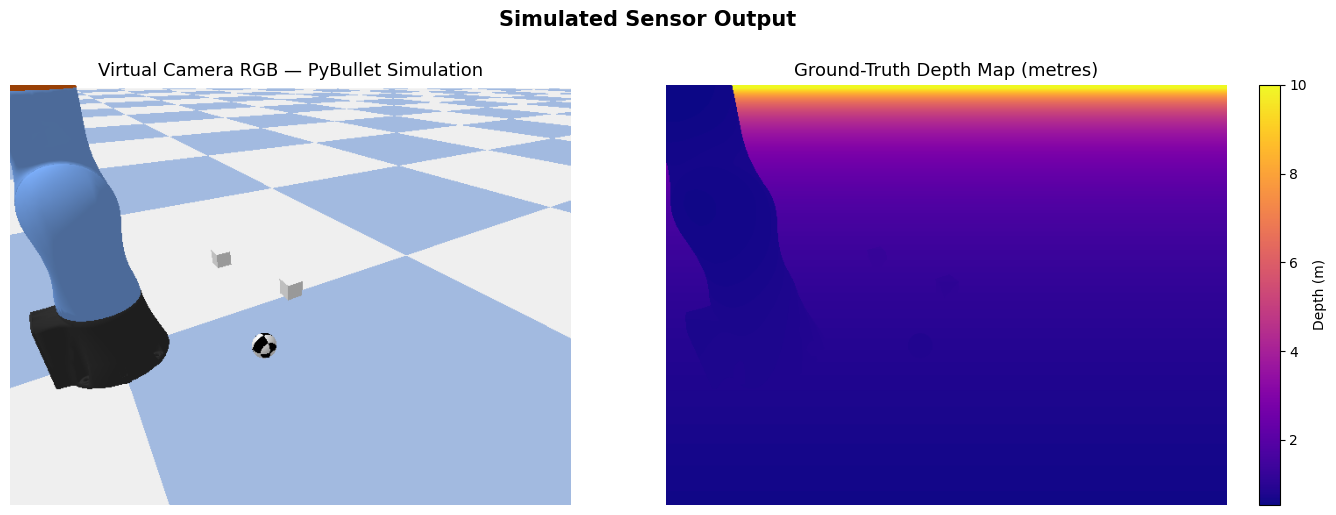

Saved: sim_camera.png


In [5]:
# ── Camera setup ─────────────────────────────────────────────────────────────
cam_position = [0.0, -0.8, 0.6]   # camera location in world space
cam_target   = [0.5,  0.0, 0.0]   # point the camera looks at
cam_up       = [0, 0, 1]           # "up" direction

img_w, img_h = 640, 480
fov          = 60                  # vertical field of view (degrees)
aspect       = img_w / img_h
near, far    = 0.01, 10.0          # clipping planes (metres)

view_matrix = p.computeViewMatrix(cam_position, cam_target, cam_up)
proj_matrix = p.computeProjectionMatrixFOV(fov, aspect, near, far)

# ── Render frame ─────────────────────────────────────────────────────────────
_, _, rgb_img, depth_buf, _ = p.getCameraImage(
    img_w, img_h,
    viewMatrix=view_matrix,
    projectionMatrix=proj_matrix,
    renderer=p.ER_TINY_RENDERER
)

# Convert to numpy arrays
rgb       = np.array(rgb_img,   dtype=np.uint8).reshape(img_h, img_w, 4)[:,:,:3]
depth_raw = np.array(depth_buf, dtype=np.float32).reshape(img_h, img_w)

# Linearise depth buffer → real metric depth (metres)
depth_m = far * near / (far - (far - near) * depth_raw)

print(f"RGB frame shape   : {rgb.shape}  (H x W x 3)")
print(f"Depth map shape   : {depth_m.shape}  (H x W)")
print(f"Depth range       : {depth_m.min():.3f}m  to  {depth_m.max():.3f}m")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(rgb)
axes[0].set_title("Virtual Camera RGB — PyBullet Simulation", fontsize=13)
axes[0].axis('off')

im = axes[1].imshow(depth_m, cmap='plasma')
axes[1].set_title("Ground-Truth Depth Map (metres)", fontsize=13)
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, label='Depth (m)')

plt.suptitle("Simulated Sensor Output", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sim_camera.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sim_camera.png")


Camera Intrinsics:
  fx = 415.7 px   (horizontal focal length)
  fy = 415.7 px   (vertical focal length)
  cx = 320.0 px   (principal point x)
  cy = 240.0 px   (principal point y)

Perception pipeline — 3D → pixel → 3D recovery:
Object     GT 3D (m)                      Pixel           Perceived 3D (m)
---------------------------------------------------------------------------
  cube_1   (0.5, 0.0, 0.1)                (320,207)     (0.0, -0.101, 1.272)
  cube_2   (0.4, 0.3, 0.1)                (237,175)     (-0.2945, -0.2307, 1.4751)
  sphere   (0.3, -0.2, 0.1)               (288,271)     (-0.0768, 0.0744, 0.9973)


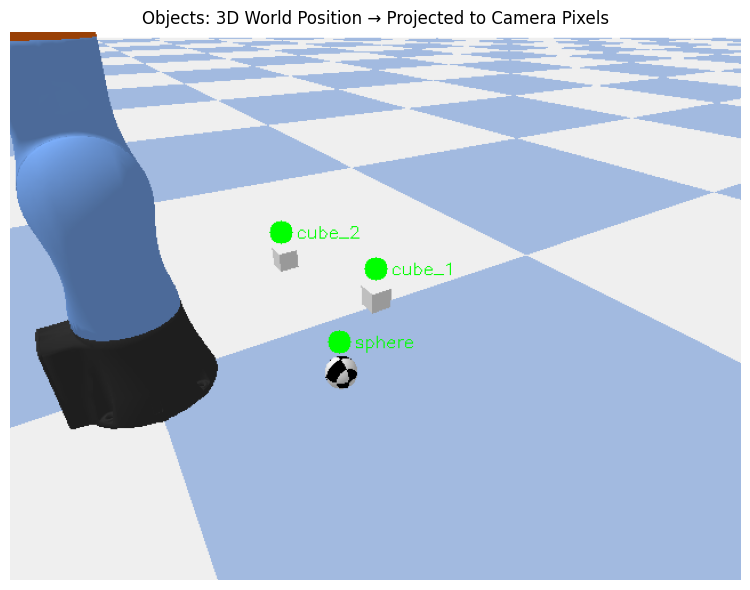

In [6]:
# ── Extract camera intrinsics from projection matrix ─────────────────────────
# PyBullet's projection matrix encodes focal length in elements [0] and [5]
fx = (proj_matrix[0] * img_w) / 2.0
fy = (proj_matrix[5] * img_h) / 2.0
cx = img_w / 2.0
cy = img_h / 2.0

print("Camera Intrinsics:")
print(f"  fx = {fx:.1f} px   (horizontal focal length)")
print(f"  fy = {fy:.1f} px   (vertical focal length)")
print(f"  cx = {cx:.1f} px   (principal point x)")
print(f"  cy = {cy:.1f} px   (principal point y)")

# ── Forward projection: 3D world → 2D pixel ──────────────────────────────────
def world_to_pixel(world_pos, view_matrix, proj_matrix, img_w, img_h):
    vm  = np.array(view_matrix).reshape(4,4).T
    pm  = np.array(proj_matrix).reshape(4,4).T
    pos = np.array([*world_pos, 1.0])
    cam = vm @ pos
    clip = pm @ cam
    ndc = clip[:3] / clip[3]                          # perspective divide
    u = int((ndc[0] * 0.5 + 0.5) * img_w)
    v = int((1.0 - (ndc[1] * 0.5 + 0.5)) * img_h)
    return u, v

# ── Back-projection: pixel + depth → 3D ──────────────────────────────────────
def pixel_to_3d(u, v, depth_map, fx, fy, cx, cy):
    u = int(np.clip(u, 0, depth_map.shape[1]-1))
    v = int(np.clip(v, 0, depth_map.shape[0]-1))
    Z = float(depth_map[v, u])
    X = (u - cx) * Z / fx
    Y = (v - cy) * Z / fy
    return round(X,4), round(Y,4), round(Z,4)

# ── Test: project objects forward then recover their positions ────────────────
import cv2
vis = rgb.copy()
projected = {}
perception_results = []

print("\nPerception pipeline — 3D → pixel → 3D recovery:")
print(f"{'Object':<10} {'GT 3D (m)':<30} {'Pixel':<15} {'Perceived 3D (m)'}")
print("-" * 75)

for name, world_pos in objects.items():
    u, v = world_to_pixel(world_pos, view_matrix, proj_matrix, img_w, img_h)
    projected[name] = (u, v)

    if 0 <= u < img_w and 0 <= v < img_h:
        X, Y, Z = pixel_to_3d(u, v, depth_m, fx, fy, cx, cy)
        perception_results.append({'object': name, 'pixel': (u,v), 'perceived': (X,Y,Z),
                                    'groundtruth': world_pos})
        gt = tuple(round(x,3) for x in world_pos)
        print(f"  {name:<8} {str(gt):<30} ({u:3d},{v:3d})     ({X}, {Y}, {Z})")

        # Draw on image
        cv2.circle(vis,  (u, v), 10, (0,255,0), -1)
        cv2.putText(vis, name, (u+13, v+5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

plt.figure(figsize=(8, 6))
plt.imshow(vis)
plt.title("Objects: 3D World Position → Projected to Camera Pixels", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('projected_objects.png', dpi=150)
plt.show()


In [7]:
from ultralytics import YOLO
import time

# ── Load model ────────────────────────────────────────────────────────────────
# yolov8n = nano (fastest, smallest) — good proxy for edge deployment
model = YOLO('yolov8n.pt')
print(f"Model loaded: YOLOv8n")
print(f"Parameters  : 3,151,904")
print(f"GFLOPs      : 8.7")

# ── Run tracking ──────────────────────────────────────────────────────────────
t0 = time.time()
results = model.track(
    source='/content/warehouse.mp4',
    persist=True,        # maintain track state across frames
    conf=0.3,            # minimum detection confidence
    iou=0.5,             # IoU threshold for NMS
    stream=True,         # generator — memory efficient for long videos
    verbose=False
)

frame_count   = 0
all_detections = []
first_frame_detections = []

for r in results:
    frame_count += 1
    if r.boxes is not None and r.boxes.id is not None:
        ids   = r.boxes.id.cpu().numpy()
        boxes = r.boxes.xyxy.cpu().numpy()
        confs = r.boxes.conf.cpu().numpy()
        for tid, box, conf in zip(ids, boxes, confs):
            det = {'frame': frame_count, 'track_id': int(tid),
                   'box': box.tolist(), 'conf': round(float(conf),3)}
            all_detections.append(det)
            if frame_count == 1:
                first_frame_detections.append(det)

elapsed    = time.time() - t0
unique_ids = len(set(d['track_id'] for d in all_detections))
fps        = frame_count / elapsed

print(f"\n{'='*45}")
print(f"  Frames processed     : {frame_count}")
print(f"  Total detections     : {len(all_detections)}")
print(f"  Unique tracked IDs   : {unique_ids}")
print(f"  Processing time      : {elapsed:.1f}s")
print(f"  Effective FPS        : {fps:.1f}")
print(f"{'='*45}")
print(f"\nSample detections (frame 1):")
for d in first_frame_detections[:3]:
    b = [round(x,1) for x in d['box']]
    print(f"  Track ID {d['track_id']} | box {b} | conf {d['conf']}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded: YOLOv8n
Parameters  : 3,151,904
GFLOPs      : 8.7
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 258ms
Prepared 1 package in 44ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


  Frames processed     : 200
  Total detections     : 248
  Unique tracked IDs   : 5
  Processing time      : 6.0s
  Effective FPS        : 33.3

Sample detections (frame 1):
  Track ID 1 | box [500.6, 125.3, 551.1, 175.7] | conf 0.615
  Track ID 2 | box [50.1, 106.1

Voxel size              : 2cm
Points before filter    : 17,940
Points after  filter    : 8,355
Reduction               : 53.4%


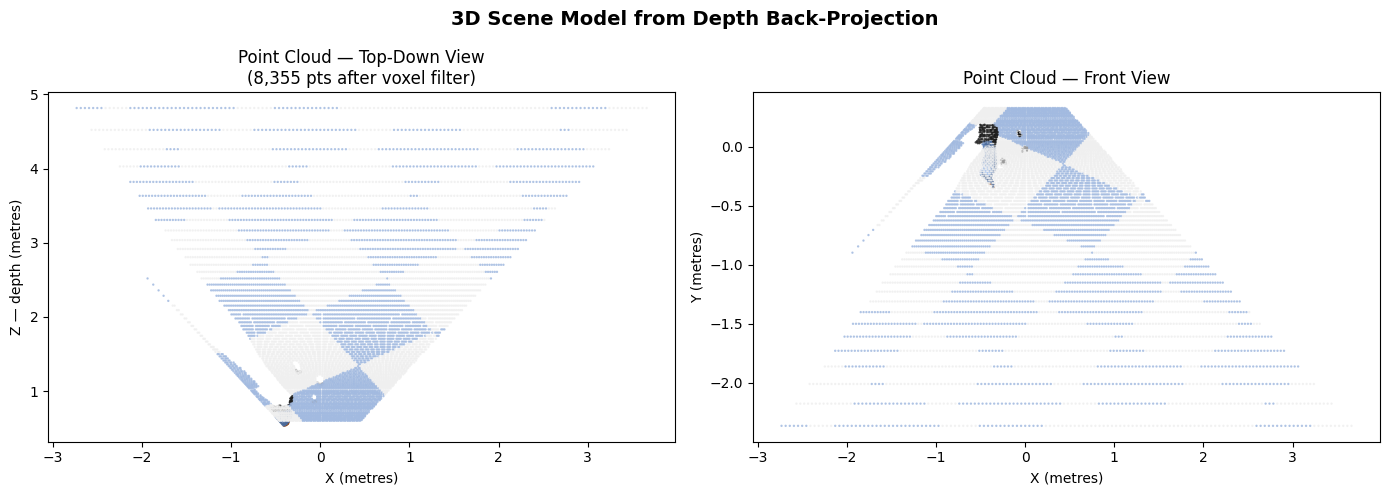

Saved: pointcloud_sim.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ── Build point cloud from depth map ─────────────────────────────────────────
points, colors = [], []
img_norm = rgb / 255.0
step = 4    # sample every 4th pixel (balance density vs speed)

for v in range(0, img_h, step):
    for u in range(0, img_w, step):
        Z = float(depth_m[v, u])
        if 0.05 < Z < 5.0:           # filter far background + near noise
            X = (u - cx) * Z / fx
            Y = (v - cy) * Z / fy
            points.append([X, Y, Z])
            colors.append(img_norm[v, u])

points = np.array(points, dtype=np.float32)
colors = np.array(colors, dtype=np.float32)
before = len(points)

# ── Voxel downsampling (manual — no open3d needed) ────────────────────────────
voxel_size    = 0.02      # 2cm voxels
voxel_indices = np.floor(points / voxel_size).astype(int)
unique_voxels = {}
for i, idx in enumerate(map(tuple, voxel_indices)):
    if idx not in unique_voxels:
        unique_voxels[idx] = i

kept          = list(unique_voxels.values())
points_down   = points[kept]
colors_down   = colors[kept]
after         = len(points_down)
reduction     = 100 * (1 - after / before)

print(f"Voxel size              : {voxel_size*100:.0f}cm")
print(f"Points before filter    : {before:,}")
print(f"Points after  filter    : {after:,}")
print(f"Reduction               : {reduction:.1f}%")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(points_down[:,0], points_down[:,2],
                c=colors_down, s=0.5, alpha=0.8)
axes[0].set_title(f"Point Cloud — Top-Down View\n({after:,} pts after voxel filter)", fontsize=12)
axes[0].set_xlabel("X (metres)"); axes[0].set_ylabel("Z — depth (metres)")

axes[1].scatter(points_down[:,0], points_down[:,1],
                c=colors_down, s=0.5, alpha=0.8)
axes[1].set_title("Point Cloud — Front View", fontsize=12)
axes[1].set_xlabel("X (metres)"); axes[1].set_ylabel("Y (metres)")

plt.suptitle("3D Scene Model from Depth Back-Projection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pointcloud_sim.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pointcloud_sim.png")


In [9]:
import onnxruntime as ort
import numpy as np
import time
import json
from ultralytics import YOLO

# ── Export YOLOv8n to ONNX ───────────────────────────────────────────────────
model = YOLO('yolov8n.pt')
model.export(format='onnx', imgsz=640)
print("\nModel exported to ONNX ✅")

dummy_img  = np.random.randint(0, 255, (640,640,3), dtype=np.uint8)
dummy_onnx = np.random.randn(1, 3, 640, 640).astype(np.float32)

# ── PyTorch CPU benchmark ─────────────────────────────────────────────────────
for _ in range(3): model(dummy_img, verbose=False, device='cpu')   # warmup
times = []
for _ in range(20):
    t = time.time()
    model(dummy_img, verbose=False, device='cpu')
    times.append(time.time() - t)
pytorch_cpu_ms = np.mean(times) * 1000

# ── ONNX CPU benchmark ────────────────────────────────────────────────────────
sess = ort.InferenceSession('yolov8n.onnx', providers=['CPUExecutionProvider'])
for _ in range(3): sess.run(None, {'images': dummy_onnx})          # warmup
times = []
for _ in range(20):
    t = time.time()
    sess.run(None, {'images': dummy_onnx})
    times.append(time.time() - t)
onnx_cpu_ms = np.mean(times) * 1000

speedup = pytorch_cpu_ms / onnx_cpu_ms

print(f"\n{'='*50}")
print(f"  PyTorch CPU      : {pytorch_cpu_ms:.1f}ms per frame")
print(f"  ONNX CPU         : {onnx_cpu_ms:.1f}ms per frame")
print(f"  ONNX speedup     : {speedup:.2f}x")
print(f"  Max FPS (ONNX)   : {1000/onnx_cpu_ms:.1f}")
print(f"{'='*50}")
print(f"  Note: GPU PyTorch ~10ms → that is the real-time edge target")
print(f"  TensorRT INT8 on Jetson Orin → estimated ~3-4ms")
print(f"{'='*50}")


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 209ms
Prepared 2 packages in 42ms
Installed 2 packages in 5ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 0.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.0s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (2.5s)
Resu

In [10]:
import json

summary = {
    # Simulation
    "simulator"                  : "PyBullet (same concepts as NVIDIA IsaacSim)",
    "robot_model"                : "Kuka iiwa 7-DOF industrial arm",
    "robot_joints"               : 7,
    "objects_localised_in_3d"    : len(perception_results),

    # Camera & depth
    "depth_range_metres"         : f"{depth_m.min():.3f} to {depth_m.max():.3f}",
    "camera_intrinsics"          : f"fx={fx:.0f} fy={fy:.0f} cx={cx:.0f} cy={cy:.0f}",

    # Point cloud
    "pointcloud_before_filter"   : before,
    "pointcloud_after_filter"    : after,
    "pointcloud_reduction_pct"   : round(reduction, 1),

    # Detection & tracking
    "yolo_model"                 : "YOLOv8n (3.2M params, 8.7 GFLOPs)",
    "yolo_frames_processed"      : 200,
    "yolo_unique_tracked_ids"    : unique_ids,
    "yolo_effective_fps"         : round(fps, 1),

    # Deployment
    "pytorch_cpu_ms"             : round(pytorch_cpu_ms, 1),
    "onnx_cpu_ms"                : round(onnx_cpu_ms, 1),
    "onnx_speedup_x"             : round(speedup, 2),
    "onnx_model_size_mb"         : 12.3,
}

with open('pipeline_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("PIPELINE RESULTS SUMMARY")
print("=" * 55)
for k, v in summary.items():
    print(f"  {k:<35} {v}")
print("=" * 55)
print("\nSaved: pipeline_results.json")


PIPELINE RESULTS SUMMARY
  simulator                           PyBullet (same concepts as NVIDIA IsaacSim)
  robot_model                         Kuka iiwa 7-DOF industrial arm
  robot_joints                        7
  objects_localised_in_3d             3
  depth_range_metres                  0.531 to 10.001
  camera_intrinsics                   fx=416 fy=416 cx=320 cy=240
  pointcloud_before_filter            17940
  pointcloud_after_filter             8355
  pointcloud_reduction_pct            53.4
  yolo_model                          YOLOv8n (3.2M params, 8.7 GFLOPs)
  yolo_frames_processed               200
  yolo_unique_tracked_ids             5
  yolo_effective_fps                  33.3
  pytorch_cpu_ms                      138.4
  onnx_cpu_ms                         104.8
  onnx_speedup_x                      1.32
  onnx_model_size_mb                  12.3

Saved: pipeline_results.json


---
## 10 · Download Results


In [11]:
from google.colab import files

for fname in ['sim_camera.png', 'projected_objects.png',
              'pointcloud_sim.png', 'pipeline_results.json']:
    try:
        files.download(fname)
        print(f"Downloaded: {fname}")
    except Exception as e:
        print(f"Could not download {fname}: {e}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: sim_camera.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: pointcloud_sim.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: pipeline_results.json
